# 🇪🇬 Egyptian ID OCR — Notebook 1: Building the Dataset

This Notebook clips card fields from images using YOLO labels.

**Inputs**: `train/`, `valid/`, `test/` (images + labels)  
**Output**: `rec/images/` + `crops_metadata.csv`

## 🆕 Two-Stage Detection Available

A new **two-stage YOLO detection pipeline** is now available using NASO7Y pre-trained models:

```
Full Image → Card Detection → Card Crop → Field Detection → Field Crops → OCR
```

**Benefits:**
- Removes background noise
- Better field localization
- Faster processing (~81 images/second)

**Results:** 57,685 field crops from 16,720 images (72.5% detection rate)

**See:** `notebooks/04_two_stage_detection.ipynb` for the new pipeline.

**Use this notebook when:**
- You have custom YOLO labels
- You want to use your own trained models
- You need fine-grained control over cropping

## 1. Setting up the environment


In [ ]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print(f"📂 Project root: {ROOT}")



📂 Project root: /home/think/project/egyption_id_ready


In [ ]:
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)



/home/think/project/egyption_id_ready/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Examine the project structure


In [ ]:
splits = {}
for split in ["train", "valid", "test"]:
    img_dir = ROOT / split / "images"
    lbl_dir = ROOT / split / "labels"
    n_imgs = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
    n_lbls = len(list(lbl_dir.glob("*.txt")))
    splits[split] = {"images": n_imgs, "labels": n_lbls}
    print(f"  {split:6}: {n_imgs:>6,} images | {n_lbls:>6,} labels")

total = sum(s["images"] for s in splits.values())
print(f"\n  Total: {total:,} images ✅")



  train : 15,669 images | 15,669 labels
  valid :    948 images |    948 labels
  test  :    103 images |    103 labels

  Total: 16,720 images ✅


## 3. Examining a sample of the labels


In [ ]:
from src.label_reader import parse_yolo_label, DEFAULT_FIELD_NAMES

# قراءة label واحد كمثال
sample_lbl = list((ROOT / "test" / "labels").glob("*.txt"))[0]
sample_img = ROOT / "test" / "images" / (sample_lbl.stem + ".jpg")

img = cv2.imread(str(sample_img))
h, w = img.shape[:2]
fields = parse_yolo_label(str(sample_lbl), w, h)

print(f"📄 Label: {sample_lbl.name}")
print(f"🖼️ Image: {w}x{h}\n")
print(f"{'Class ID':<10} {'Field Name':<18} {'BBox':}")
print("─" * 55)
for f in fields:
    print(f"{f['class_id']:<10} {f['class_name']:<18} {f['bbox']}")



📄 Label: 71_jpeg.rf.59d7fc971ccc1ffff1497276708b8154.txt
🖼️ Image: 640x640

Class ID   Field Name         BBox
───────────────────────────────────────────────────────
3          birth_date         [525, 72, 595, 150]
4          religion           [338, 131, 608, 264]
0          job_title          [526, 200, 617, 270]
1          photo              [372, 241, 625, 387]
6          address            [114, 565, 271, 634]
5          name               [323, 363, 640, 518]
2          expiry_date        [333, 0, 336, 54]


## 4. Preview the fields on the image

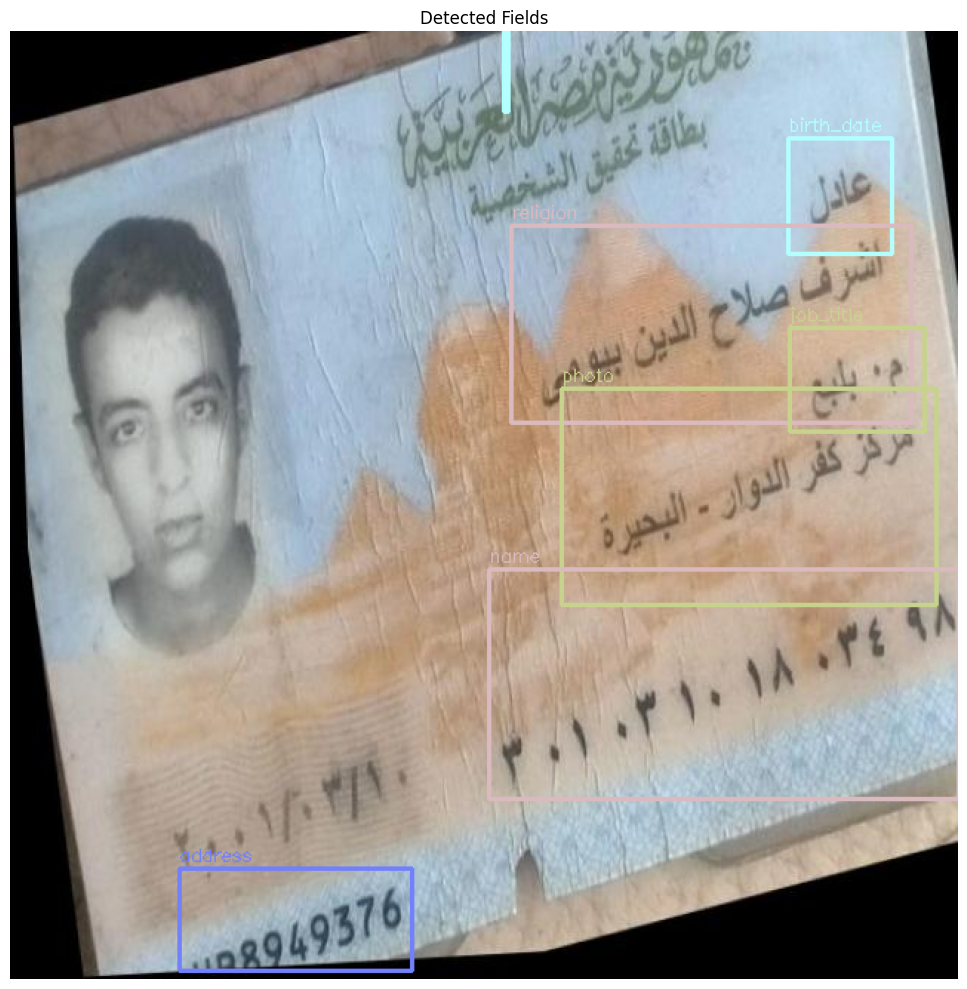

In [ ]:
vis = img.copy()
colors = plt.cm.Set3(np.linspace(0, 1, 24))[:, :3] * 255

for f in fields:
    x1, y1, x2, y2 = f["bbox"]
    c = tuple(int(v) for v in colors[f["class_id"] % 24])
    cv2.rectangle(vis, (x1, y1), (x2, y2), c, 2)
    cv2.putText(vis, f["class_name"], (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, c, 1)

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Detected Fields")
plt.axis("off")
plt.tight_layout()
plt.show()



birth_date ==> first_name
religion ==> last_name
jop_title==> address line 1
photo ==> address line 2
name == nid
address ==> serial number 

## 5. Cut fields from all splits


In [ ]:
from src.crop_builder import build_crops_from_split
from src.label_reader import OCR_FIELDS

OUTPUT_DIR = ROOT / "rec" / "images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_dfs = []
for split in ["train", "valid", "test"]:
    split_path = ROOT / split
    if not (split_path / "images").exists():
        print(f"⚠️ Skipping {split}")
        continue
    df = build_crops_from_split(
        split=split,
        split_path=split_path,
        output_dir=OUTPUT_DIR,
    )
    all_dfs.append(df)

crops_df = pd.concat(all_dfs, ignore_index=True)
crops_df.to_csv(ROOT / "crops_metadata.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ Total crops: {len(crops_df):,}")



[train] Cropping: 100%|██████████| 15669/15669 [00:24<00:00, 630.44it/s]


  ✅ 15666 images → 80234 crops | ⚠️ 3 without labels | ❌ 0 errors


[valid] Cropping: 100%|██████████| 948/948 [00:01<00:00, 601.61it/s]


  ✅ 948 images → 4735 crops | ⚠️ 0 without labels | ❌ 0 errors


[test] Cropping: 100%|██████████| 103/103 [00:00<00:00, 657.32it/s]


  ✅ 103 images → 782 crops | ⚠️ 0 without labels | ❌ 0 errors

✅ Total crops: 85,751


## 6. Dataset statistics


In [ ]:
print(f"\n📊 Crops per split:")
display(crops_df["split"].value_counts().to_frame("count"))

print(f"\n📊 Crops per field:")
display(crops_df["field"].value_counts().to_frame("count"))




📊 Crops per split:


,count
split,
train,80234
valid,4735
test,782



📊 Crops per field:


,count
field,
job_title,72866
religion,2156
name,2144
address,2134
expiry_date,2068
birth_date,1364
national_id,1160
gender,389
governorate,386


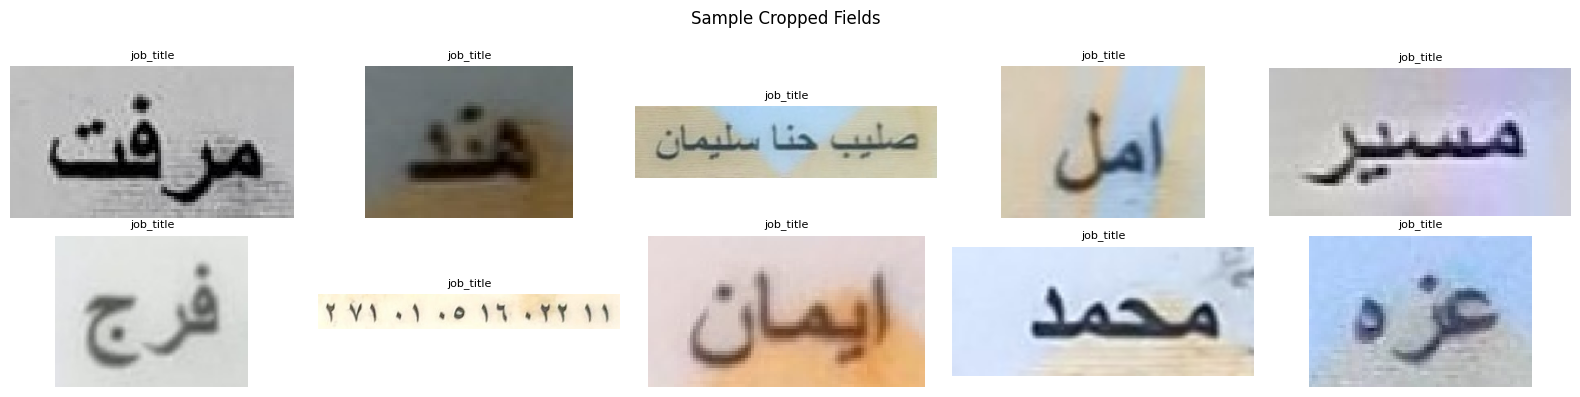

In [ ]:
# معاينة عينة من الحقول المقصوصة
fig, axes = plt.subplots(2, 5, figsize=(16, 4))
samples = crops_df.sample(min(10, len(crops_df)), random_state=42)

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img_path = ROOT / row["image_path"]
    if img_path.exists():
        crop = cv2.imread(str(img_path))
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(row["field"], fontsize=8)
    ax.axis("off")

plt.suptitle("Sample Cropped Fields", fontsize=12)
plt.tight_layout()
plt.show()



## 7. Field quality


In [ ]:
from src.preprocessing import assess_field_quality

quality_records = []
for _, row in tqdm(crops_df.sample(min(500, len(crops_df))).iterrows(),
                   desc="Assessing quality"):
    img_path = ROOT / row["image_path"]
    if not img_path.exists():
        continue
    img = cv2.imread(str(img_path))
    q = assess_field_quality(img)
    q["field"] = row["field"]
    quality_records.append(q)

qdf = pd.DataFrame(quality_records)
print("\n📊 Quality Distribution:")
display(qdf["quality"].value_counts().to_frame("count"))
print(f"\n⚠️ Issues found:")
all_issues = [i for lst in qdf["issues"] for i in lst]
display(pd.Series(all_issues).value_counts().to_frame("count"))



Assessing quality: 500it [00:00, 3305.09it/s]


📊 Quality Distribution:


,count
quality,
good,484
medium,14
poor,2



⚠️ Issues found:


,count
blurry,7
low_contrast,6
too_small,3
overexposed,2


---
✅ **الـ Dataset جاهز!** → شغّل الـ Notebook التاني: `02_label_and_train.py`
